In [90]:
import tensorflow as tf
import collections
import numpy as np
from tensorflow.keras import layers, Model



In [91]:
def build_realtime_denoiser(window_size=10):
    inp = layers.Input(shape=(window_size, 1))

    # Causal Conv1D (padding='causal' ensures only past context)
    x = layers.Conv1D(16, kernel_size=3, padding='causal', activation='relu')(inp)
    x = layers.Conv1D(8, kernel_size=3, padding='causal', activation='relu')(x)
    x = layers.Conv1D(1, kernel_size=1, padding='valid', activation='linear')(x)

    # Output only the last timestep (current sample)
    # out = layers.Lambda(lambda z: z[:, -1, :])(x)
    out = layers.Lambda(lambda z: z[:, window_size - 1, :])(x)
    return Model(inp, out)

model = build_realtime_denoiser(window_size=10)
model.compile(optimizer='adam', loss='mse')

In [92]:
def generate_data(num_samples=1000, noise_factor=0.5):
    np.random.seed(42)
    t = np.linspace(0, 1, num_samples, dtype=np.float32)
    s = np.sin(2 * np.pi * t, dtype=np.float32)  # Clean signal
    n = noise_factor * np.random.normal(size=num_samples)  # Noise
    x = s + n  # Noisy signal
    x.astype(dtype=np.float32)
    s.astype(dtype=np.float32)
    return x, s


def create_seq(x:np.array, seq_len=10, n_samples=1000):
    # seq = np.zeros(shape=(seq_len, n_samples//seq_len))
    new_x = []
    seq = []
    for i in range(seq_len, n_samples):
        seq.append(x[i-seq_len:i])
    seq = np.array(seq)
    new_x.append(seq)
    return np.array(new_x)
        

In [93]:
n_samples = 1000

In [94]:
X, y = generate_data(n_samples)
x_test, y_test = generate_data(n_samples)

In [95]:
X.shape

(1000,)

In [96]:
X = create_seq(X, n_samples=n_samples)
X = np.squeeze(X)

x_test_inf = create_seq(x_test, n_samples=n_samples)
x_test_inf = np.squeeze(x_test_inf)

In [97]:
X.shape

(990, 10)

In [98]:
model.fit(X, y, epochs=20, batch_size=64, validation_split=0.1)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3586 - val_loss: 0.1210
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2124 - val_loss: 0.0866
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1089 - val_loss: 0.0673
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0636 - val_loss: 0.0623
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0530 - val_loss: 0.0614
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0490 - val_loss: 0.0593
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0465 - val_loss: 0.0595
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0448 - val_loss: 0.0595
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0438 - val_loss: 0.0589
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0430 - val_loss: 0.0588
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0421 - val_loss: 0.0582
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0416 - val_l

In [99]:
print(x_test.shape, y_test.shape)

(1000,) (1000,)


In [100]:
y_pred = []
for arr in x_test_inf:
    seq = np.array(arr)
    seq = np.expand_dims(seq, axis=0)
    val_pred = model.predict(seq)
    print(val_pred.shape)
    y_pred.append(val_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
(1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
(1, 1)
1/1 ━━━━━━

KeyboardInterrupt: 

In [11]:
print(y_pred[0])

[[0.24993443]]


In [26]:
pred = np.array(y_pred)

In [27]:
pred.shape

(90, 1, 1)

In [28]:
pred = np.squeeze(pred, axis = 1)
pred = np.squeeze(pred, axis = 1)

In [66]:
x_test_inf.shape

(990, 10)

In [101]:
y_pred = model.predict(x_test_inf, verbose=0)

In [86]:
y_pred.shape

(490, 1)

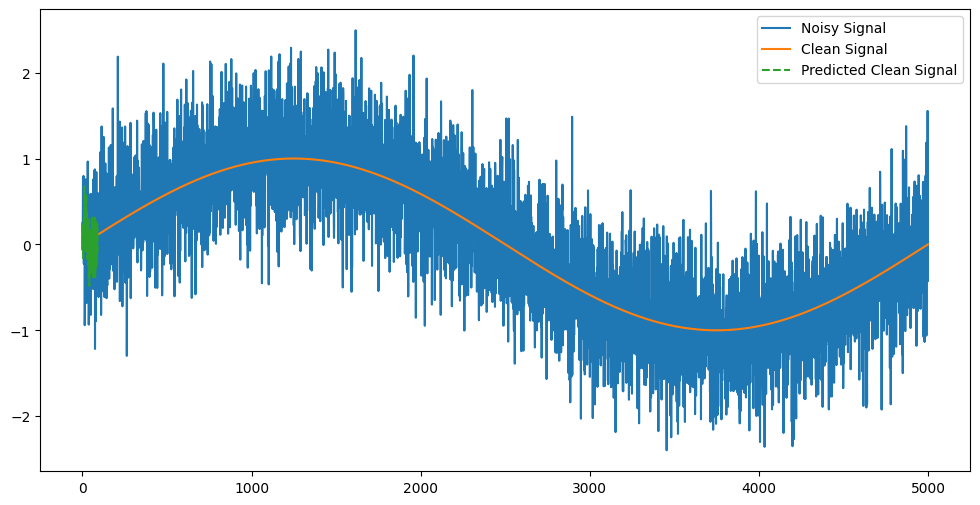

In [38]:
from matplotlib import pyplot as plt


plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(y_test, label='Clean Signal')
plt.plot(pred, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
# plt.savefig(f'results/{model_name}.png')

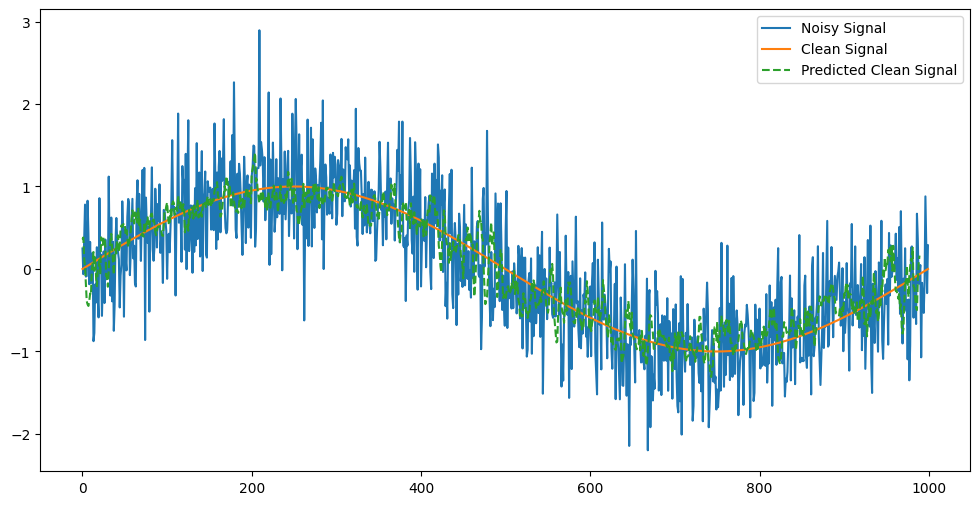

In [102]:
from matplotlib import pyplot as plt


plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(y_test, label='Clean Signal')
plt.plot(y_pred, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
# plt.savefig(f'results/{model_name}.png')

In [103]:
model_name = "best_sequence_model"

In [104]:
model.save(f'checkpoints/{model_name}.keras')

# Check TF Lite model

In [ ]:
y_pred = []
for arr in x_test_inf:
    seq = np.array(arr)
    seq = np.expand_dims(seq, axis=0)
    val_pred = model.predict(seq)
    print(val_pred.shape)
    y_pred.append(val_pred)


In [21]:
interpreter = tf.lite.Interpreter(model_path=f"{model_name}.tflite")
interpreter.allocate_tensors()


input = interpreter.get_input_details()[0]  # Model has single input.
print(input['shape'])

[ 1 10  1]


/home/sergiusz/ML_Filter/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [22]:
output = interpreter.get_output_details()[0]  # Model has single output.
input = interpreter.get_input_details()[0]  # Model has single input.
# input_data = tf.constant(1., shape=[1, 1])

output_list = []
for arr in x_test_inf:
    seq = np.array(arr, np.float32)
    seq = np.expand_dims(seq, axis=0)
    seq = np.expand_dims(seq, axis=2)
    # print(seq.shape)
    interpreter.set_tensor(input['index'], seq)
    interpreter.invoke()
    
    val_output = (interpreter.get_tensor(output['index']))
    output_list.append(val_output[0][0])



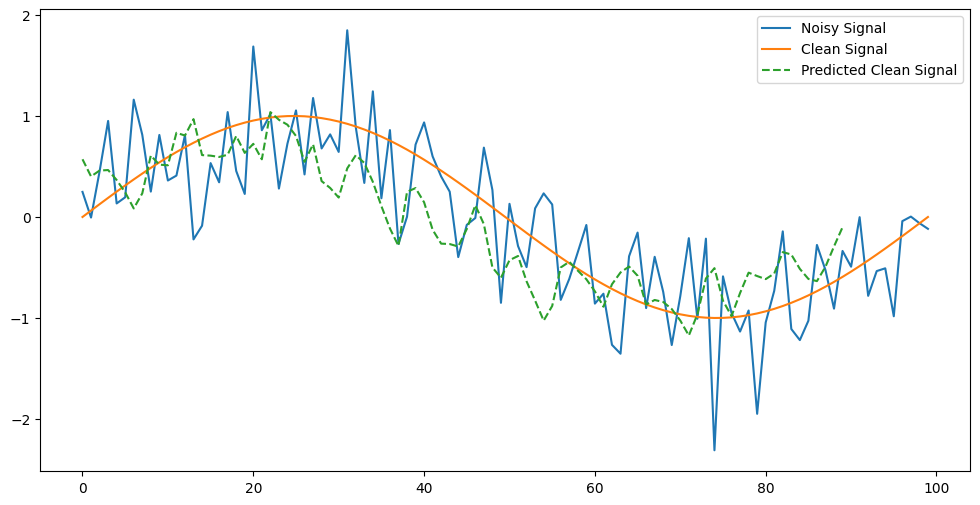

In [23]:
from matplotlib import pyplot as plt


plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(y_test, label='Clean Signal')
plt.plot(output_list, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()